# Thermal-Contrast U-Net — обучение (Variant A)

Клип кадров → **2D contrast maps** → static U-Net.

| preset | Каналы |
|--------|--------|
| `minimal` | max−min |
| `combo` | max−min, max−t₀, σ(t) |
| `pca` | max−min + PCA₁(t) |

Ноутбук показывает: **как клип сворачивается**, live-кривые, превью каждые N эпох.


In [1]:
# === параметры ===
PRESET = "combo"              # minimal | delta | combo | pca | full
EPOCHS = 30
BATCH_SIZE = 8
TEST_EVERY = 4
NUM_WORKERS = 0
LR = 3e-4
WEIGHT_DECAY = 1e-4
POS_WEIGHT = 10.0
COMPILE = False
DEVICE = "auto"
RESUME = None
PREVIEW_EVERY = 3             # превью pred + contrast каждые N эпох
YAML = None


In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output, display

CHANNEL_TITLES = {
    "maxmin": "max − min",
    "maxfirst": "max − t₀",
    "minfirst": "min − t₀",
    "lastfirst": "last − t₀",
    "std": "σ(t)",
    "mean": "⟨t⟩",
    "pca1": "PCA₁(t)",
}


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for base in ([start, start.parent] if start.name == "notebooks" else [start]):
        for p in [base, *base.parents]:
            p = p.resolve()
            if (p / "data").is_dir() and (p / "irt_data").is_dir():
                return p
    raise FileNotFoundError(f"корень репо не найден, cwd={start}")


ROOT = find_project_root()
TC = ROOT / "models" / "Thermal-Contrast"
SEG = ROOT / "models"
if str(TC) not in sys.path:
    sys.path.insert(0, str(TC))
for p in (SEG, ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.append(sp)

from common.device import get_device
from common.mps_train import setup_mps_env, suggest_num_workers
from data import ContrastCropDataset, build_contrast_loaders
from features import PRESETS, collapse_temporal, normalize_contrast
from train import train_one

setup_mps_env()
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

device = get_device(DEVICE)
yaml_path = TC / "dataset_contrast.yaml" if YAML is None else Path(YAML)
if not yaml_path.is_absolute():
    yaml_path = (ROOT / yaml_path).resolve()
nw = suggest_num_workers(device) if NUM_WORKERS is None else NUM_WORKERS

print(f"ROOT={ROOT.name}  device={device}  preset={PRESET}  channels={PRESETS[PRESET]}")
print(f"yaml={yaml_path.relative_to(ROOT)}  epochs={EPOCHS}  bs={BATCH_SIZE}")


ROOT=thermal-control-ya-project  device=mps  preset=combo  channels=['maxmin', 'maxfirst', 'std']
yaml=models/Thermal-Contrast/dataset_contrast.yaml  epochs=30  bs=8


In [3]:
train_loader, test_loader, train_ds, test_ds = build_contrast_loaders(
    yaml_path,
    preset=PRESET,
    test_every=TEST_EVERY,
    batch_size=BATCH_SIZE,
    num_workers=nw,
)
print(
    f"train {len(train_ds.video_ids)} vid / {len(train_ds)} samples\n"
    f"test  {len(test_ds.video_ids)} vid / {len(test_ds)} samples\n"
    f"in_ch={train_ds.num_channels}  {train_ds.channels}"
)


train 44 vid / 352 samples
test  12 vid / 12 samples
in_ch=3  ['maxmin', 'maxfirst', 'std']


## 1. Как клип сворачивается в contrast maps

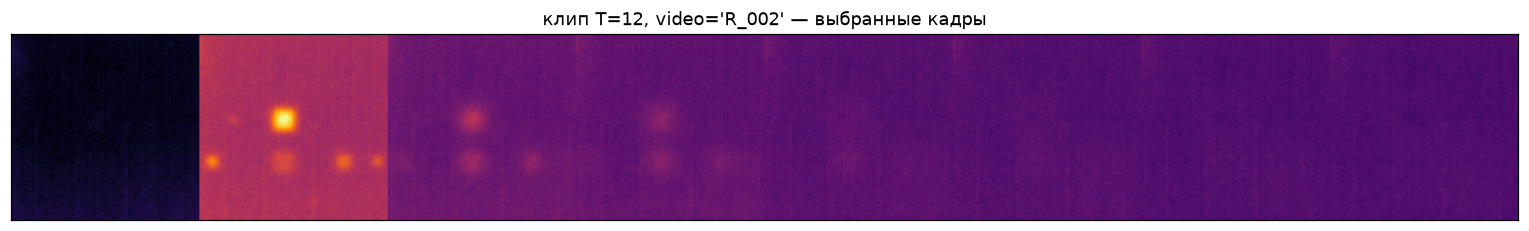

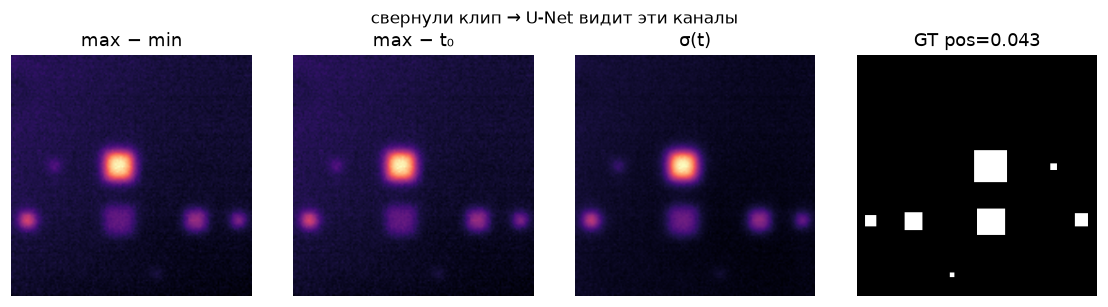

In [4]:
def show_collapse_pipeline(ds, idx: int = 0, *, max_frames: int = 8) -> None:
    """Сырой клип (T кадров) → contrast channels → маска."""
    base = ds.base
    s = base[idx]
    raw = s["image"].numpy()  # (T, 1, H, W)
    T = raw.shape[0]
    pick = np.linspace(0, T - 1, num=min(max_frames, T), dtype=int)

    feat_np = normalize_contrast(collapse_temporal(raw[:, 0], ds.channels))
    mask_np = ds[idx][1].squeeze().numpy()
    n_ch = len(ds.channels)

    # row 1: temporal strip
    fig1, ax1 = plt.subplots(figsize=(14, 2.2))
    strip = np.hstack([raw[t, 0] for t in pick])
    ax1.imshow(strip, cmap="inferno", aspect="auto")
    ax1.set_title(f"клип T={T}, video={s['video_id']!r} — выбранные кадры")
    ax1.set_yticks([])
    ax1.set_xticks([])
    fig1.tight_layout()
    plt.show()

    # row 2: contrast + GT
    fig2, ax2 = plt.subplots(1, n_ch + 1, figsize=(2.6 * (n_ch + 1), 2.8))
    if n_ch + 1 == 1:
        ax2 = [ax2]
    for c, name in enumerate(ds.channels):
        ax2[c].imshow(feat_np[c], cmap="magma")
        ax2[c].set_title(CHANNEL_TITLES.get(name, name))
        ax2[c].axis("off")
    ax2[-1].imshow(mask_np, cmap="gray", vmin=0, vmax=1)
    ax2[-1].set_title(f"GT pos={mask_np.mean():.3f}")
    ax2[-1].axis("off")
    fig2.suptitle("свернули клип → U-Net видит эти каналы", fontsize=11)
    fig2.tight_layout()
    plt.show()


INDEX = 0
show_collapse_pipeline(train_ds, INDEX)


## 2. Обучение — live-кривые + превью

In [5]:
def plot_training_dashboard(history, *, epoch, end_epoch, best_iou, best_epoch, title=""):
    if not history:
        return
    ep = [float(r["epoch"]) for r in history]
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    fig.suptitle(title or f"Thermal-Contrast [{PRESET}]  epoch {epoch}/{end_epoch}", fontsize=12)

    specs = [
        ("train_loss", "test_loss", "Loss"),
        ("train_iou", "test_iou", "IoU"),
        ("train_dice", "test_dice", "Dice"),
    ]
    for ax, (tk, vk, ylab) in zip(axes.flat[:3], specs):
        tr = [float(r[tk]) for r in history]
        te = [float(r[vk]) for r in history]
        ax.plot(ep, tr, "o-", label="train", ms=4, lw=1.5)
        ax.plot(ep, te, "s-", label="test", ms=4, lw=1.5)
        if best_epoch in ep:
            j = ep.index(float(best_epoch))
            ax.axvline(best_epoch, color="green", ls="--", alpha=0.4, label=f"best@{best_epoch}")
        ax.set_title(ylab)
        ax.set_xlabel("epoch")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    ax = axes[1, 1]
    ax.axis("off")
    last = history[-1]
    lines = [
        f"epoch {epoch} / {end_epoch}",
        f"train loss {last['train_loss']:.4f}  test {last['test_loss']:.4f}",
        f"train IoU  {last['train_iou']:.4f}  test {last['test_iou']:.4f}",
        f"train Dice {last['train_dice']:.4f}  test {last['test_dice']:.4f}",
        f"best test IoU {best_iou:.4f} @ {best_epoch}",
        f"preset={PRESET}  ch={train_ds.channels}",
    ]
    ax.text(0.05, 0.95, "\n".join(lines), va="top", family="monospace", fontsize=10,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3))
    fig.tight_layout()
    display(fig)
    plt.close(fig)


def preview_prediction(model, ds, device, *, idx=0, title=""):
    model.eval()
    feat, mask = ds[idx]
    with torch.no_grad():
        prob = torch.sigmoid(model(feat.unsqueeze(0).to(device))).squeeze().cpu().numpy()
    pred = (prob > 0.5).astype(np.float32)
    gt = mask.squeeze().numpy()
    n = feat.shape[0]
    from common.metrics import dice_score, iou_score
    d = dice_score(pred, gt)
    iou = iou_score(pred, gt)

    fig, axes = plt.subplots(2, max(n, 3), figsize=(2.4 * max(n, 3), 5))
    for c in range(n):
        axes[0, c].imshow(feat[c].numpy(), cmap="magma")
        axes[0, c].set_title(ds.channels[c], fontsize=9)
        axes[0, c].axis("off")
    for c in range(n, axes.shape[1]):
        axes[0, c].axis("off")

    axes[1, 0].imshow(gt, cmap="gray", vmin=0, vmax=1)
    axes[1, 0].set_title("GT")
    axes[1, 0].axis("off")
    axes[1, 1].imshow(prob, cmap="magma", vmin=0, vmax=1)
    axes[1, 1].set_title("prob")
    axes[1, 1].axis("off")
    axes[1, 2].imshow(pred, cmap="gray", vmin=0, vmax=1)
    axes[1, 2].set_title(f"pred Dice={d:.3f}")
    axes[1, 2].axis("off")
    mid = min(1, n - 1)
    if n > 1:
        axes[1, mid].imshow(feat[mid].numpy(), cmap="magma")
        axes[1, mid].contour(pred, colors="lime", levels=[0.5], linewidths=1)
        axes[1, mid].set_title("overlay")
        axes[1, mid].axis("off")
    for c in range(3, axes.shape[1]):
        axes[1, c].axis("off")
    if title:
        fig.suptitle(f"{title}  IoU={iou:.3f}", fontsize=10)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


def _on_epoch_end(tracker, row, epoch, end_epoch, best_iou, best_epoch, opt, model):
    clear_output(wait=True)
    print(tracker.format_line(row, end_epoch))
    print(f"lr={opt.param_groups[0]['lr']:.2e}")
    plot_training_dashboard(
        tracker.history,
        epoch=epoch,
        end_epoch=end_epoch,
        best_iou=best_iou,
        best_epoch=best_epoch,
    )
    if PREVIEW_EVERY and epoch % PREVIEW_EVERY == 0:
        preview_prediction(model, test_ds, device, idx=0, title=f"test[0] @ epoch {epoch}")


[contrast-combo] epoch  30/30  loss 0.3039/1.1801  IoU 0.811/0.649  test dice 0.787  P 0.786  R 0.789
lr=1.50e-05


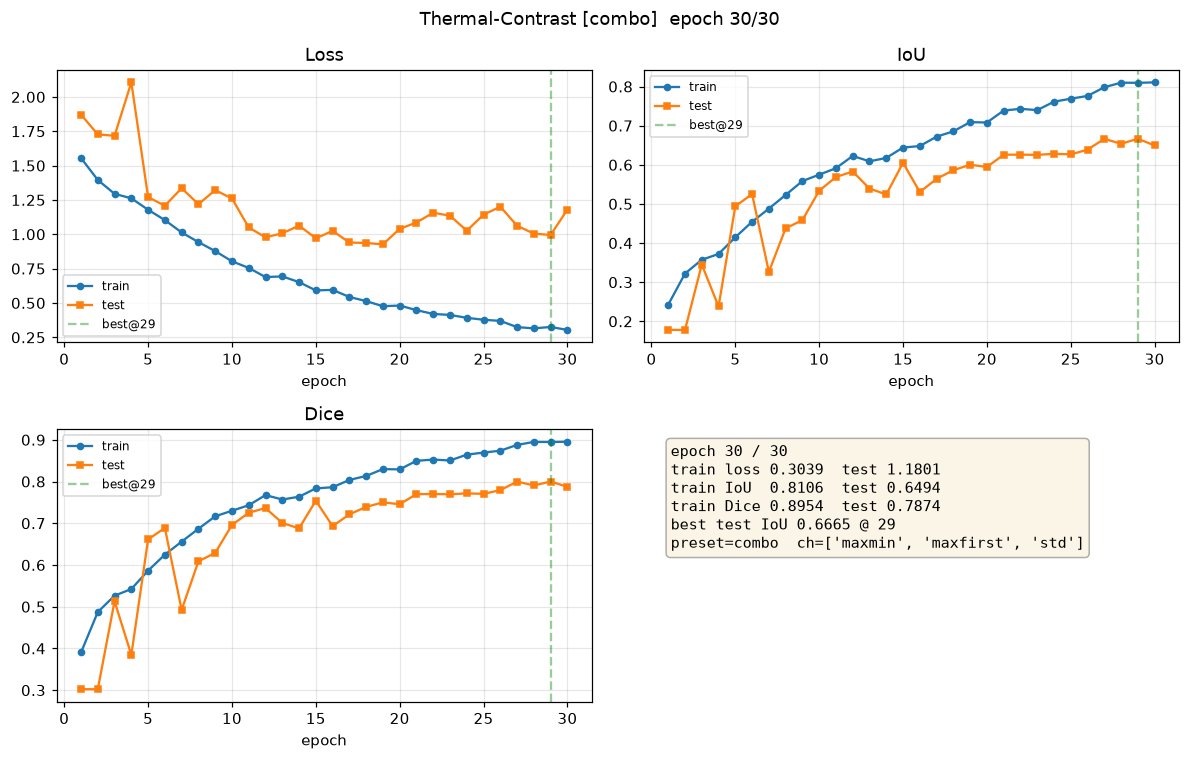

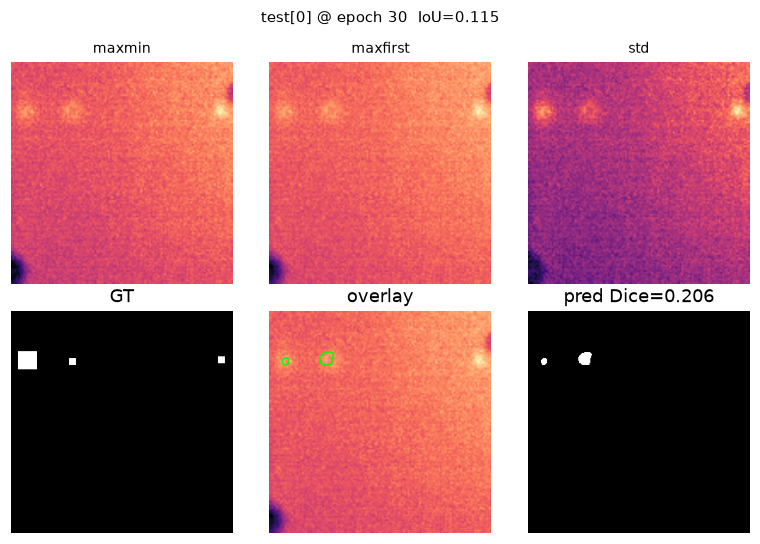

done contrast-combo. best test IoU 0.6665 @ 29
history -> /Users/user/Education/CVYandexCamp/thermal-control-ya-project/models/Thermal-Contrast/runs/combo/history.json

=== done: best test IoU 0.6665 @ epoch 29 ===
history: /Users/user/Education/CVYandexCamp/thermal-control-ya-project/models/Thermal-Contrast/runs/combo/history.json


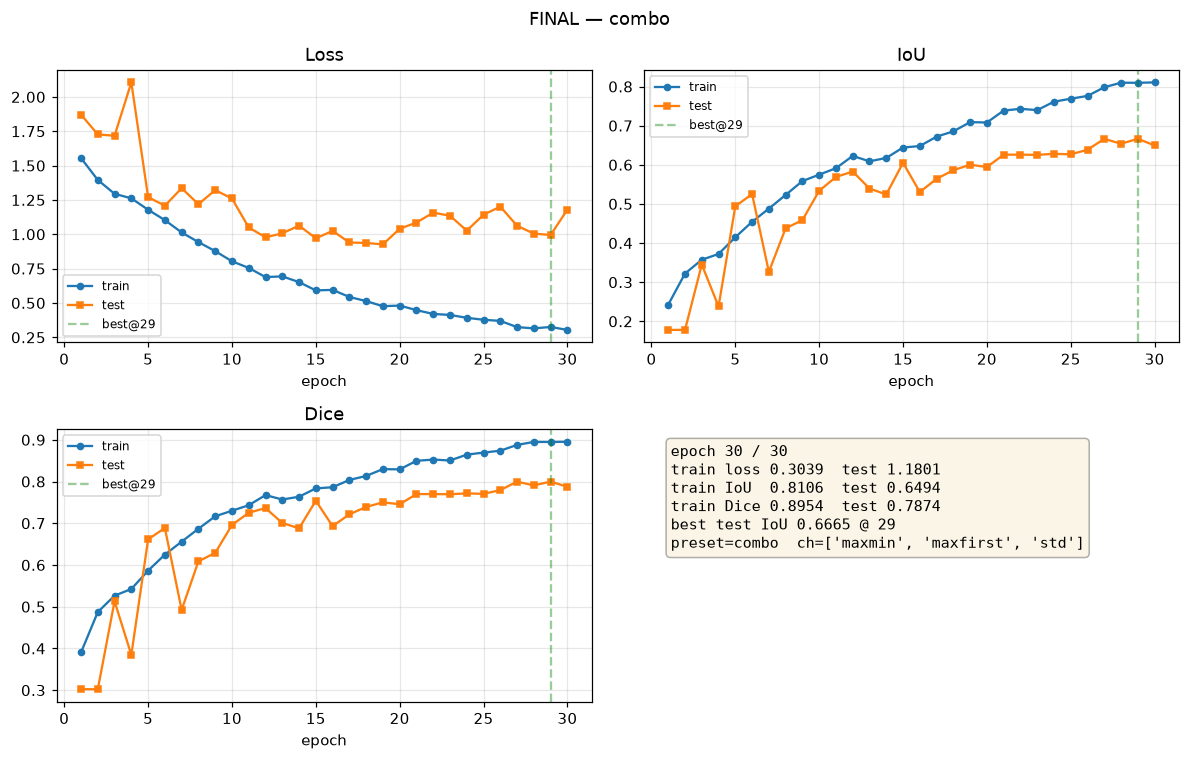

In [6]:
tracker, model, best_iou, best_epoch = train_one(
    PRESET,
    yaml_path,
    EPOCHS,
    device,
    test_every=TEST_EVERY,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    pos_weight=POS_WEIGHT,
    compile_model=COMPILE,
    num_workers=nw,
    resume=RESUME,
    on_epoch_end=_on_epoch_end,
)

print(f"\n=== done: best test IoU {best_iou:.4f} @ epoch {best_epoch} ===")
print(f"history: {tracker.json_path}")
plot_training_dashboard(
    tracker.history,
    epoch=int(tracker.history[-1]["epoch"]),
    end_epoch=int(tracker.history[-1]["epoch"]),
    best_iou=best_iou,
    best_epoch=best_epoch,
    title=f"FINAL — {PRESET}",
)


## 3. Test-сэмплы после обучения

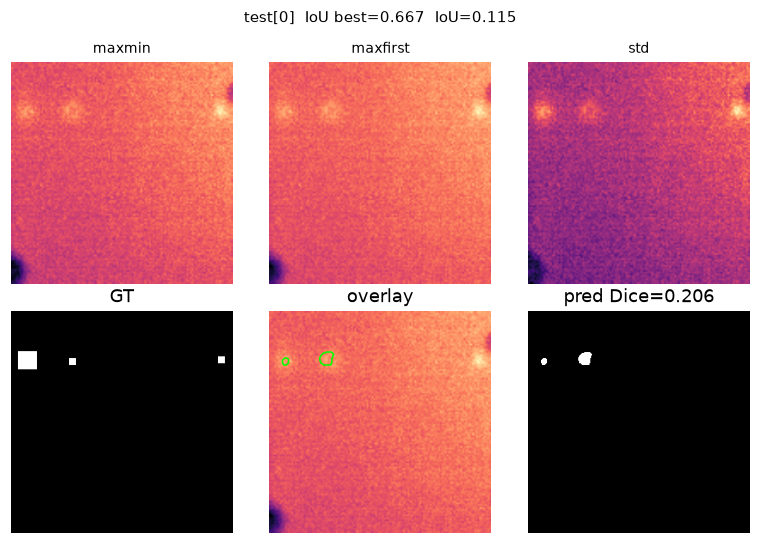

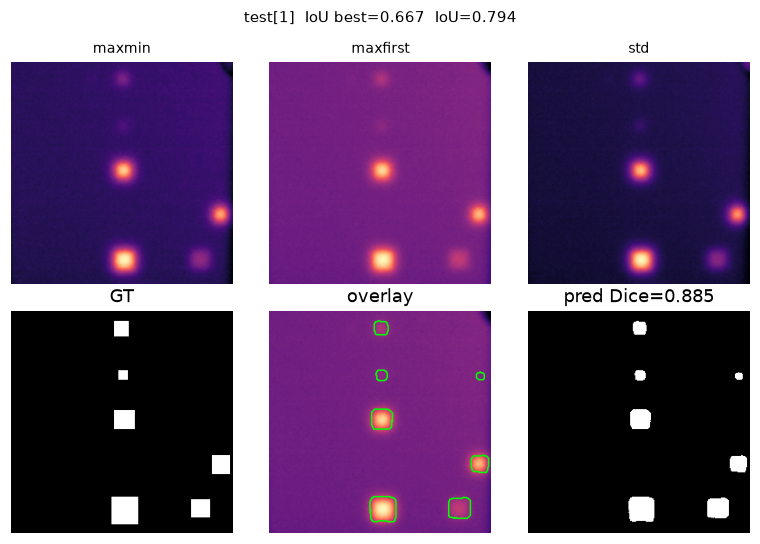

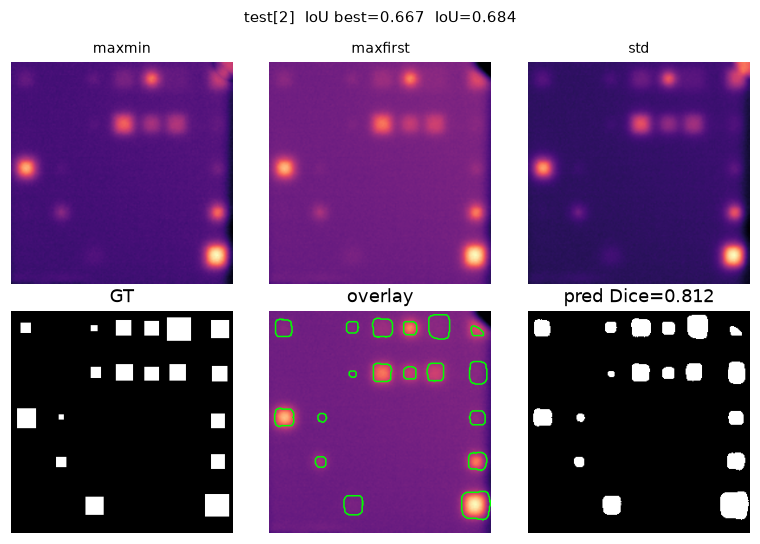

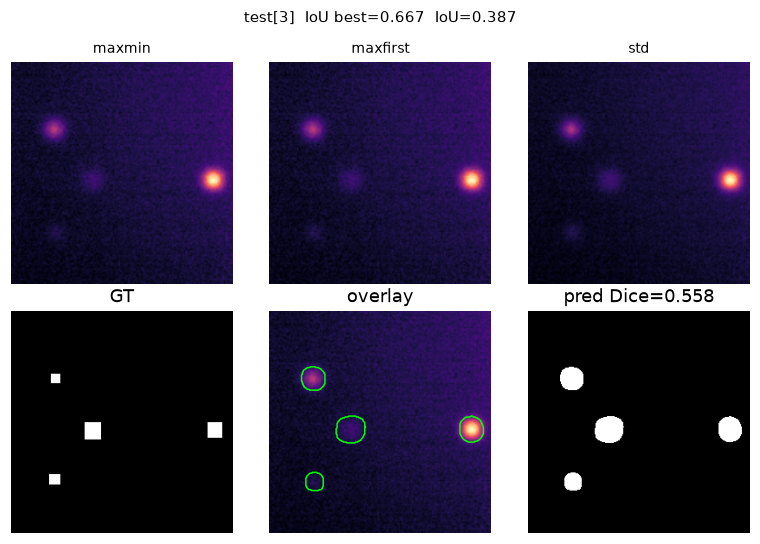

In [ ]:
for i in range(len(test_ds)):
    preview_prediction(
        model, test_ds, device, idx=i,
        title=f"test[{i}]  IoU best={best_iou:.3f}",
    )
